# Import Library


In [ ]:
from google.colab import drive

import torch
import torch.nn as nn

import pandas as pd
import numpy as np
from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras import layers
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import ParameterGrid

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import pickle

# Load Data

In [ ]:
df = pd.read_csv('dataset.csv')

# Visualization

In [ ]:
value_count = df['class'].value_counts()
print(value_count)

1    410
0    220
Name: class, dtype: int64


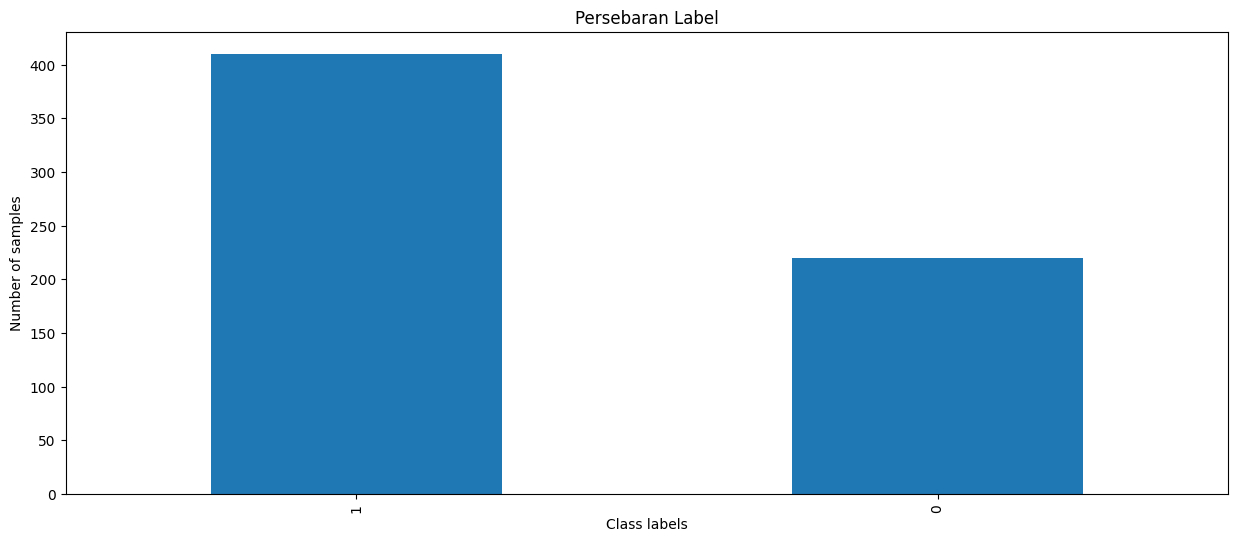

In [ ]:
value_count.plot(kind='bar',
              figsize=(15, 6))

plt.xlabel('Class labels')
plt.ylabel('Number of samples')

plt.title('Persebaran Label')

plt.show()

# Undersampling

In [ ]:
from sklearn.utils import resample

df_major = df[df['class']!=0]
df_minor = df[df['class']==0]

df_downsampled = resample(df_major, n_samples=220, random_state=42)
df = pd.concat([df_downsampled, df_minor])

# Split Dataset (Train and Validation)

In [ ]:
training_set, test_set = train_test_split(df, test_size=0.1, random_state=42)

# Preprocessing

## K-mer Encoding

In [ ]:
KMER_SIZE = 3

def build_kmers(sequence, ksize=KMER_SIZE):
    kmers = []
    n_kmers = len(sequence) - ksize + 1

    for i in range(n_kmers):
        kmer = sequence[i:i + ksize]
        kmers.append(kmer)

    return kmers

In [ ]:
kmer_label_training_dict = {"kmer": [], "label": []}
for index, row in training_set.iterrows():
  seq = row['sequence']
  label = row['class']
  kmer = build_kmers(seq)
  kmer_label_training_dict['kmer'].append(kmer)
  kmer_label_training_dict['label'].append(label)

In [ ]:
kmer_test_dict = {"kmer": [], "label": []}
for index, row in test_set.iterrows():
  seq = row['sequence']
  label = row['class']
  kmer = build_kmers(seq)
  kmer_test_dict['kmer'].append(kmer)
  kmer_test_dict['label'].append(label)

In [ ]:
X_train, Y_train = kmer_label_training_dict['kmer'], kmer_label_training_dict['label']
X_test, Y_test = kmer_test_dict['kmer'], kmer_test_dict['label']

## Word2vec

In [ ]:
# Word2vec
w2v_model = Word2Vec(X_train, min_count=1, window=5, vector_size=100, workers=2)

In [ ]:
sample_seq = X_train[0]
sample_seq_kmer = sample_seq[0]
print(f'sample kmer: {sample_seq_kmer}')
print(f'Sample kmer w2v: {w2v_model.wv[sample_seq_kmer]}')

sample kmer: TGA
Sample kmer w2v: [ 6.14415526e-01  7.65864253e-01  1.03903711e+00  7.58384317e-02
  7.30070353e-01 -7.74348497e-01 -4.11173612e-01  5.88677287e-01
  2.53566980e-01 -2.16583118e-01  6.39981031e-01  1.26622707e-01
  3.42516094e-01  3.06930840e-01 -3.39950137e-02 -1.23532683e-01
 -2.18835041e-01  2.90097386e-01  1.61951825e-01 -9.99329150e-01
 -3.66536379e-01 -6.44174933e-01  1.31675497e-01 -7.01382518e-01
 -6.90920711e-01 -5.68484962e-01 -2.58333206e-01  1.30132425e+00
 -3.00730169e-01  1.80538669e-01 -6.53205097e-01  3.21594298e-01
 -9.20740049e-03 -1.58071414e-01 -3.25117737e-01 -6.97817087e-01
 -1.33686200e-01 -1.41273499e-01 -6.19816244e-01 -2.25802049e-01
 -1.11593306e-01 -2.73670524e-01  8.60521279e-04  1.62441224e-01
  1.07142948e-01  9.95917991e-02  9.01729882e-01  4.65439469e-01
 -3.27279359e-01 -1.39300659e-01  9.42000508e-01  4.78652924e-01
  1.25843406e+00 -2.32590720e-01 -7.65444458e-01 -6.84470713e-01
 -1.10236049e-01  4.85503785e-02  1.66058596e-02  2.6464

## Normalize

In [ ]:
# Normalize
def create_seqs_embedding(w2v_model, seqs):
  seqs_embedding = np.array([np.zeros(100)])
  for seq in seqs:
    vector = np.zeros(100)
    for word in seq:
      vector += w2v_model.wv[word]
    number_of_word_in_seq = len(seq)
    normalized_vector = vector / number_of_word_in_seq
    seqs_embedding = np.append(seqs_embedding, [normalized_vector], axis=0)

  return seqs_embedding[1: ]

In [ ]:
X_train_embedding = create_seqs_embedding(w2v_model, X_train)

In [ ]:
X_test_embedding = create_seqs_embedding(w2v_model, X_test)

# Build Model

## Tensorflow

In [ ]:
model = keras.Sequential([
    keras.layers.LSTM(units=50, activation='relu', input_shape=(100,1)),

    keras.layers.Dense(units=50, activation='relu'),
    keras.layers.Dense(units=50, activation='relu'),

    keras.layers.Dropout(rate=0.2),

    keras.layers.Dense(units=1, activation='sigmoid')
])

In [ ]:
model.compile(optimizer='adam',
              loss=tf.losses.binary_crossentropy,
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    np.array(X_train_embedding),
    np.array(Y_train),
    validation_data=(np.array(X_test_embedding), np.array(Y_test)),
    batch_size=16,
    epochs=50
)

Epoch 1/50
25/25 [==============================] - 6s 13ms/step - loss: 0.6140 - accuracy: 0.7778 - val_loss: 0.4971 - val_accuracy: 0.8636
Epoch 2/50
25/25 [==============================] - 0s 5ms/step - loss: 0.4667 - accuracy: 0.8207 - val_loss: 0.3906 - val_accuracy: 0.8636
Epoch 3/50
25/25 [==============================] - 0s 5ms/step - loss: 0.4494 - accuracy: 0.8106 - val_loss: 0.3837 - val_accuracy: 0.8636
Epoch 4/50
25/25 [==============================] - 0s 6ms/step - loss: 0.4385 - accuracy: 0.8157 - val_loss: 0.3798 - val_accuracy: 0.8636
Epoch 5/50
25/25 [==============================] - 0s 5ms/step - loss: 0.4389 - accuracy: 0.8056 - val_loss: 0.3681 - val_accuracy: 0.8864
Epoch 6/50
25/25 [==============================] - 0s 5ms/step - loss: 0.4265 - accuracy: 0.8283 - val_loss: 0.3818 - val_accuracy: 0.8636
Epoch 7/50
25/25 [==============================] - 0s 5ms/step - loss: 0.4180 - accuracy: 0.8131 - val_loss: 0.3480 - val_accuracy: 0.8864
Epoch 8/50
25/25 [=

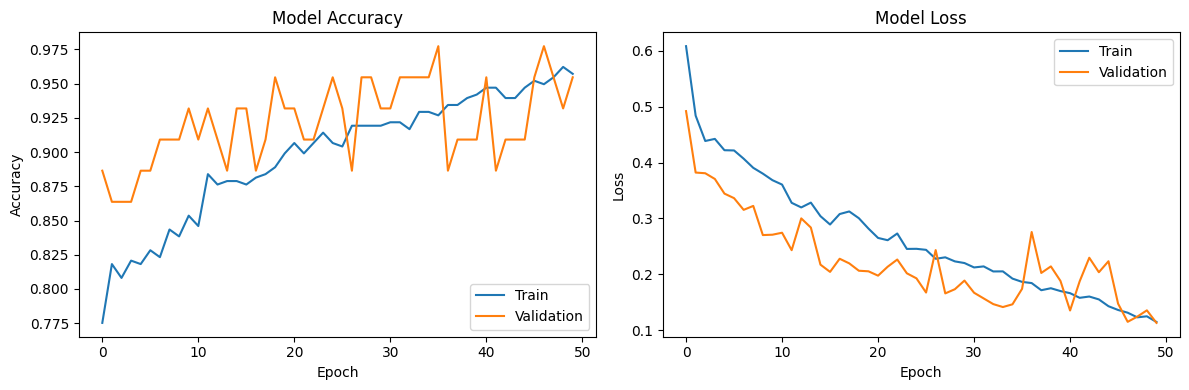

In [ ]:
# Plot training and testing accuracy and loss
plt.figure(figsize=(12, 4))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot training loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

# Testing

## Input Data Test

In [ ]:
testing = test_set.copy()
testing = testing.drop('class', axis=1)
testing.head()

,sequence
45,GGCCAGGCAGGGACAGGGCCAGGTGCGCCCATGGAAGGACCTAGGT...
263,GGAGAATAAATGGCACCATGCAGGAACAAGGAAGAGAAGTGGACAT...
127,CACGTTTCTTGGAGTACTCTACGTCTGAGTGTCATTTCTTCAATGG...
35,AGCCCAGGCTTCCTTCCAGGATCTGCTCCTCGGCCCCTTTACTCTA...
107,GGGCGGGCCTAGGCTCATCTCCACAGGGGAGAACACACAGACAGCA...


## K-Mer Encoding

In [ ]:
testing['Hasil K-Mer'] = X_test
testing.head()

,sequence,Hasil K-Mer
45,GGCCAGGCAGGGACAGGGCCAGGTGCGCCCATGGAAGGACCTAGGT...,"[GGC, GCC, CCA, CAG, AGG, GGC, GCA, CAG, AGG, ..."
263,GGAGAATAAATGGCACCATGCAGGAACAAGGAAGAGAAGTGGACAT...,"[GGA, GAG, AGA, GAA, AAT, ATA, TAA, AAA, AAT, ..."
127,CACGTTTCTTGGAGTACTCTACGTCTGAGTGTCATTTCTTCAATGG...,"[CAC, ACG, CGT, GTT, TTT, TTC, TCT, CTT, TTG, ..."
35,AGCCCAGGCTTCCTTCCAGGATCTGCTCCTCGGCCCCTTTACTCTA...,"[AGC, GCC, CCC, CCA, CAG, AGG, GGC, GCT, CTT, ..."
107,GGGCGGGCCTAGGCTCATCTCCACAGGGGAGAACACACAGACAGCA...,"[GGG, GGC, GCG, CGG, GGG, GGC, GCC, CCT, CTA, ..."


## Word2Vec

In [ ]:
# Contoh Hasil Word2vec pada data pertama
X_test_embedding[0]

array([ 0.14126229, -0.08531228, -0.04611234, -0.0622638 , -0.00663322,
       -0.02364326, -0.11550922,  0.09007919, -0.21199071, -0.14960598,
        0.02097826,  0.00102958,  0.02898533, -0.11789167,  0.21810041,
        0.01031442,  0.15235593, -0.16317447,  0.00387829, -0.33381362,
        0.15570301,  0.07276155,  0.24266827, -0.02153143, -0.21186369,
        0.19432437, -0.10191987, -0.10587132,  0.03670478,  0.11977355,
        0.19663915, -0.06387027, -0.02672985, -0.16820511,  0.08643382,
        0.18198158, -0.07630836,  0.03331054, -0.20661604, -0.08367896,
        0.19952458, -0.21543725,  0.13939927,  0.19617521,  0.1596648 ,
       -0.12473471, -0.15574736, -0.17349251,  0.00719988, -0.04602465,
        0.05038648, -0.10197905, -0.05184225,  0.08306481, -0.1623985 ,
        0.02755172,  0.0218513 ,  0.10808846, -0.12946713, -0.17848573,
        0.03267221, -0.04749625,  0.35031639,  0.18550106, -0.01651115,
        0.26250899, -0.11779564, -0.03411258, -0.24401784, -0.26

## Model Classification

In [ ]:
y_pred_prob = model.predict(X_test_embedding)
y_pred = np.where(y_pred_prob > 0.5, 1, 0)

2/2 [==============================] - 0s 3ms/step


In [ ]:
test_set.head(5)

,sequence,class
45,GGCCAGGCAGGGACAGGGCCAGGTGCGCCCATGGAAGGACCTAGGT...,0
263,GGAGAATAAATGGCACCATGCAGGAACAAGGAAGAGAAGTGGACAT...,1
127,CACGTTTCTTGGAGTACTCTACGTCTGAGTGTCATTTCTTCAATGG...,0
35,AGCCCAGGCTTCCTTCCAGGATCTGCTCCTCGGCCCCTTTACTCTA...,0
107,GGGCGGGCCTAGGCTCATCTCCACAGGGGAGAACACACAGACAGCA...,0


In [ ]:
x = y_pred[4]

if x == 0:
    print('Hasil Klasifikasi: Diabetes Melitus Tipe 1')
else:
    print('Hasil Klasifikasi: Diabetes Melitus Tipe 2')

Hasil Klasifikasi: Diabetes Melitus Tipe 1


# Evaluation

In [ ]:
accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.9545454545454546
Precision: 1.0
Recall: 0.9166666666666666
F1-score: 0.9565217391304348


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(Y_test, y_pred))

[[20  0]
 [ 2 22]]


In [ ]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        20
           1       1.00      0.92      0.96        24

    accuracy                           0.95        44
   macro avg       0.95      0.96      0.95        44
weighted avg       0.96      0.95      0.95        44

